# Actor-Critic RL for the Unbalanced Disk

A2C training on the lecturer-provided simulator via `gym.make("unbalanced-disk-sincos-v0", ...)`. The simulator dynamics stay in `UnbalancedDisk.py`. The RL training reward is computed externally in this notebook, so we can tune swing-up, balancing, omega penalty, action penalty, and entropy without editing the environment.


## 1. Imports and environment wrapper


In [1]:
from pathlib import Path
import sys
import time

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from stable_baselines3 import A2C
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

# Make the local lecturer-provided package importable when running this notebook from its folder.
repo_root = Path.cwd()
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "gym_unbalanced_disk").exists():
        repo_root = parent
        break
sys.path.insert(0, str(repo_root))

import gym_unbalanced_disk  # registers the unbalanced disk Gym environments

SEED = 7
np.random.seed(SEED)
USE_CUDA_FOR_MLP = False  # CPU is usually faster for A2C + small MLP; env stepping is the bottleneck.
DEVICE = "cuda" if USE_CUDA_FOR_MLP and torch.cuda.is_available() else "cpu"
EPISODE_STEPS = 300
SIMULATION_STEPS = 1200  # 1200 steps is about 24 seconds at sleep_s=1/50
TRAIN_EPISODES = 1000
TOTAL_TIMESTEPS = TRAIN_EPISODES * EPISODE_STEPS
MODEL_PATH = Path("a2c_unbalanced_disk_long")
ENTROPY_COEF = 0.005  # stable main-training value for swing-up and balancing
REWARD_WEIGHTS = {
    "swing_up": 1.0,
    "balance": 4.0,
    "low_speed": 2.0,
    "omega_penalty": 0.05,
    "action_penalty": 0.003,
}

print(f"Using device: {DEVICE}")
print(f"Training for {TRAIN_EPISODES} episodes = {TOTAL_TIMESTEPS:,} timesteps")
print(f"A2C entropy coefficient: {ENTROPY_COEF}")
print(f"External reward weights: {REWARD_WEIGHTS}")
# Guardrails: fail fast if an old/autosaved notebook state comes back.
assert USE_CUDA_FOR_MLP is False, "Expected CPU for this A2C MLP run. Set USE_CUDA_FOR_MLP intentionally if changing this."
assert "fine_balance" not in REWARD_WEIGHTS, "Old strict reward is active; reload the stable notebook."
assert "upright_error_penalty" not in REWARD_WEIGHTS, "Old strict reward is active; reload the stable notebook."


Using device: cpu
Training for 1000 episodes = 300,000 timesteps
A2C entropy coefficient: 0.005
External reward weights: {'swing_up': 1.0, 'balance': 4.0, 'low_speed': 2.0, 'omega_penalty': 0.05, 'action_penalty': 0.003}


In [2]:
def wrap_angle(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi


def external_balance_reward(theta, omega, action, umax, weights=REWARD_WEIGHTS):
    """Reward used for RL training, computed outside UnbalancedDisk.py."""
    theta_wrapped = wrap_angle(theta)
    upright_error = np.pi - abs(theta_wrapped)

    swing_up_reward = (1.0 - np.cos(theta_wrapped)) / 2.0
    balance_bonus = np.exp(-(upright_error ** 2) / (2 * 0.30 ** 2))
    low_speed_bonus = np.exp(-(omega ** 2) / (2 * 1.5 ** 2)) * np.exp(
        -(upright_error ** 2) / (2 * 0.45 ** 2)
    )
    omega_penalty = (omega / 10.0) ** 2
    action_penalty = (action / umax) ** 2

    return (
        weights["swing_up"] * swing_up_reward
        + weights["balance"] * balance_bonus
        + weights["low_speed"] * low_speed_bonus
        - weights["omega_penalty"] * omega_penalty
        - weights["action_penalty"] * action_penalty
    )


class DiskSB3Env(gym.Env):
    """SB3 adapter around the registered sin/cos unbalanced-disk environment.

    The simulator is created from UnbalancedDisk.py through
    gym.make("unbalanced-disk-sincos-v0", ...). Gymnasium TimeLimit is
    controlled with max_episode_steps. Observations come from the sin/cos
    environment. Rewards for training are computed externally here.
    """

    metadata = {"render_modes": ["human"]}

    def __init__(self, dt=0.025, umax=3.0, max_episode_steps=EPISODE_STEPS):
        super().__init__()
        self.umax = umax
        self.max_episode_steps = max_episode_steps
        self.env = gym.make(
            "unbalanced-disk-sincos-v0",
            dt=dt,
            umax=umax,
            max_episode_steps=max_episode_steps,
            disable_env_checker=True,
        )

        original_reset = self.env.unwrapped.reset

        def reset_with_options(seed=None, options=None):
            return original_reset(seed=seed)

        self.env.unwrapped.reset = reset_with_options
        self.action_space = gym.spaces.Box(
            low=np.array([-umax], dtype=np.float32),
            high=np.array([umax], dtype=np.float32),
            dtype=np.float32,
        )
        self.observation_space = self.env.observation_space

    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
        obs, info = self.env.reset(seed=seed, options=options)
        return obs.astype(np.float32), info

    def step(self, action):
        u = float(np.asarray(action, dtype=np.float32).reshape(-1)[0])
        obs, env_reward, terminated, truncated, info = self.env.step(u)

        theta = self.env.unwrapped.th
        omega = self.env.unwrapped.omega
        theta_wrapped = wrap_angle(theta)
        upright_error = np.pi - abs(theta_wrapped)
        train_reward = external_balance_reward(theta, omega, u, self.umax)

        info = {
            **info,
            "theta": float(theta),
            "theta_wrapped": float(theta_wrapped),
            "omega": float(omega),
            "upright_error": float(upright_error),
            "env_reward": float(env_reward),
            "train_reward": float(train_reward),
        }
        return obs.astype(np.float32), float(train_reward), terminated, truncated, info

    def render(self):
        return self.env.render()

    def close(self):
        self.env.close()


def make_env(seed=SEED):
    def _init():
        env = DiskSB3Env(dt=0.025, umax=3.0, max_episode_steps=EPISODE_STEPS)
        env = Monitor(env)
        env.reset(seed=seed)
        return env
    return _init

# Smoke-test one simulator step before training.
test_env = make_env()()
obs, info = test_env.reset(seed=SEED)
next_obs, reward, terminated, truncated, info = test_env.step(np.array([0.0], dtype=np.float32))
print("Gym env id:", test_env.unwrapped.env.spec.id)
print("TimeLimit max steps:", test_env.unwrapped.env.spec.max_episode_steps)
print("obs:", obs)
print("next obs:", next_obs)
print("external training reward:", reward)
print("environment reward:", info["env_reward"])
print("raw theta:", info["theta"], "upright error:", info["upright_error"])
test_env.close()


Gym env id: unbalanced-disk-sincos-v0
TimeLimit max steps: 300
obs: [ 1.7233450e-03  9.9999851e-01 -5.8421087e-05]
next obs: [ 9.0063334e-04  9.9999958e-01 -3.4038945e-05]
external training reward: 7.137030484246827e-07
environment reward: 2.350860100124887e-11
raw theta: 0.0016895565104488464 upright error: 3.1399030970793445


## 2. Train a longer actor-critic policy

`A2C` uses an actor network for the continuous voltage command and a critic network for value estimates. Training length is controlled by `TRAIN_EPISODES`; each training episode is capped by `EPISODE_STEPS` using Gymnasium's `TimeLimit`. The visible simulation can use a different cap through `SIMULATION_STEPS`. The training reward is computed externally in the wrapper.


In [3]:
train_env = DummyVecEnv([make_env(SEED)])

model = A2C(
    "MlpPolicy",
    train_env,
    seed=SEED,
    verbose=1,
    learning_rate=7e-4,
    n_steps=32,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=ENTROPY_COEF,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs={"net_arch": [64, 64]},
    device=DEVICE,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)
#model.save(MODEL_PATH)
print(f"Saved trained model to {MODEL_PATH}.zip")
train_env.close()


Using cpu device


Output()

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 300      |
|    ep_rew_mean        | 19.4     |
| time/                 |          |
|    fps                | 849      |
|    iterations         | 100      |
|    time_elapsed       | 3        |
|    total_timesteps    | 3200     |
| train/                |          |
|    entropy_loss       | -1.42    |
|    explained_variance | 0.00256  |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -0.0566  |
|    std                | 0.998    |
|    value_loss         | 0.00188  |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 300      |
|    ep_rew_mean        | 26.3     |
| time/                 |          |
|    fps                | 643      |
|    iterations         | 200      |
|    time_elapsed       | 9        |
|    total_timesteps    | 6400     |
| train/                |          |
|    entropy_loss       | -1.43    |
|    explained_variance | -0.323   |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        | -0.051   |
|    std                | 1.01     |
|    value_loss         | 0.00141  |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 300      |
|    ep_rew_mean        | 28.8     |
| time/                 |          |
|    fps                | 575      |
|    iterations         | 300      |
|    time_elapsed       | 16       |
|    total_timesteps    | 9600     |
| train/                |          |
|    entropy_loss       | -1.44    |
|    explained_variance | -0.00778 |
|    learning_rate      | 0.0007   |
|    n_updates          | 299      |
|    policy_loss        | 0.0386   |
|    std                | 1.02     |
|    value_loss         | 0.000866 |
------------------------------------


...

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 300      |
|    ep_rew_mean        | 56.8     |
| time/                 |          |
|    fps                | 374      |
|    iterations         | 9000     |
|    time_elapsed       | 768      |
|    total_timesteps    | 288000   |
| train/                |          |
|    entropy_loss       | -3.16    |
|    explained_variance | -0.198   |
|    learning_rate      | 0.0007   |
|    n_updates          | 8999     |
|    policy_loss        | 40.3     |
|    std                | 5.68     |
|    value_loss         | 223      |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 300      |
|    ep_rew_mean        | 67.7     |
| time/                 |          |
|    fps                | 377      |
|    iterations         | 9100     |
|    time_elapsed       | 772      |
|    total_timesteps    | 291200   |
| train/                |          |
|    entropy_loss       | -3.17    |
|    explained_variance | -0.0884  |
|    learning_rate      | 0.0007   |
|    n_updates          | 9099     |
|    policy_loss        | 0.00371  |
|    std                | 5.74     |
|    value_loss         | 1.87e-06 |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 300      |
|    ep_rew_mean        | 81.9     |
| time/                 |          |
|    fps                | 379      |
|    iterations         | 9200     |
|    time_elapsed       | 775      |
|    total_timesteps    | 294400   |
| train/                |          |
|    entropy_loss       | -3.16    |
|    explained_variance | 0.752    |
|    learning_rate      | 0.0007   |
|    n_updates          | 9199     |
|    policy_loss        | -1.39    |
|    std                | 5.72     |
|    value_loss         | 0.285    |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 300      |
|    ep_rew_mean        | 97.9     |
| time/                 |          |
|    fps                | 381      |
|    iterations         | 9300     |
|    time_elapsed       | 779      |
|    total_timesteps    | 297600   |
| train/                |          |
|    entropy_loss       | -3.17    |
|    explained_variance | 0.00144  |
|    learning_rate      | 0.0007   |
|    n_updates          | 9299     |
|    policy_loss        | -1.44    |
|    std                | 5.76     |
|    value_loss         | 0.23     |
------------------------------------


Saved trained model to a2c_unbalanced_disk_long.zip


## Optional: fine-tune residual upright error

Run this after the first long training if the policy swings up and balances with a small steady error. It continues from the current model with lower entropy and the tighter reward above.


In [4]:
RUN_FINE_TUNE = False

if RUN_FINE_TUNE:
    FINE_TUNE_EPISODES = 300
    FINE_TUNE_TIMESTEPS = FINE_TUNE_EPISODES * EPISODE_STEPS

    REWARD_WEIGHTS.update({
        "low_speed": 3.0,
        "omega_penalty": 0.08,
        "action_penalty": 0.002,
    })
    model.ent_coef = 0.0005

    fine_tune_env = DummyVecEnv([make_env(SEED + 100)])
    model.set_env(fine_tune_env)
    model.learn(total_timesteps=FINE_TUNE_TIMESTEPS, reset_num_timesteps=False, progress_bar=True)
    model.save(MODEL_PATH)
    print(f"Fine-tuned and saved model to {MODEL_PATH}.zip")
    fine_tune_env.close()
else:
    print("Fine-tune skipped. Set RUN_FINE_TUNE = True only after the main policy balances reliably.")


Fine-tune skipped. Set RUN_FINE_TUNE = True only after the main policy balances reliably.


## 3. Evaluate one rollout

After longer training, the deterministic mean action is usually the cleaner policy to inspect. If it still does not swing up, try `deterministic=False` to see the exploratory policy.


In [5]:
def rollout(policy, deterministic=True, seed=SEED + 1, render=False, sleep_s=0.0, max_steps=EPISODE_STEPS):
    env = DiskSB3Env(dt=0.025, umax=3.0, max_episode_steps=max_steps)
    obs, info = env.reset(seed=seed)
    observations, actions, rewards, infos = [], [], [], []

    try:
        for _ in range(max_steps):
            action, _ = policy.predict(obs, deterministic=deterministic)
            next_obs, reward, terminated, truncated, info = env.step(action)
            observations.append(obs)
            actions.append(float(np.asarray(action).reshape(-1)[0]))
            rewards.append(reward)
            infos.append(info)
            obs = next_obs
            if render:
                env.render()
                time.sleep(sleep_s)
            if terminated or truncated:
                break
    finally:
        env.close()

    return np.asarray(observations), np.asarray(actions), np.asarray(rewards), infos

obs_hist, action_hist, reward_hist, info_hist = rollout(model, deterministic=True)
upright_errors = np.array([info["upright_error"] for info in info_hist])
omega_hist = np.array([info["omega"] for info in info_hist])
env_reward_hist = np.array([info["env_reward"] for info in info_hist])
print(f"steps: {len(reward_hist)}")
print(f"external return: {reward_hist.sum():.2f}")
print(f"environment return: {env_reward_hist.sum():.2f}")
print(f"mean upright error: {upright_errors.mean():.3f} rad")
print(f"final upright error: {upright_errors[-1]:.3f} rad")
print(f"max |omega|: {np.abs(omega_hist).max():.2f} rad/s")
print(f"max |u|: {np.abs(action_hist).max():.2f} V")


steps: 300
external return: 38.42
environment return: 0.00
mean upright error: 2.407 rad
final upright error: 2.412 rad
max |omega|: 6.35 rad/s
max |u|: 3.00 V


## 4. Plot the first result


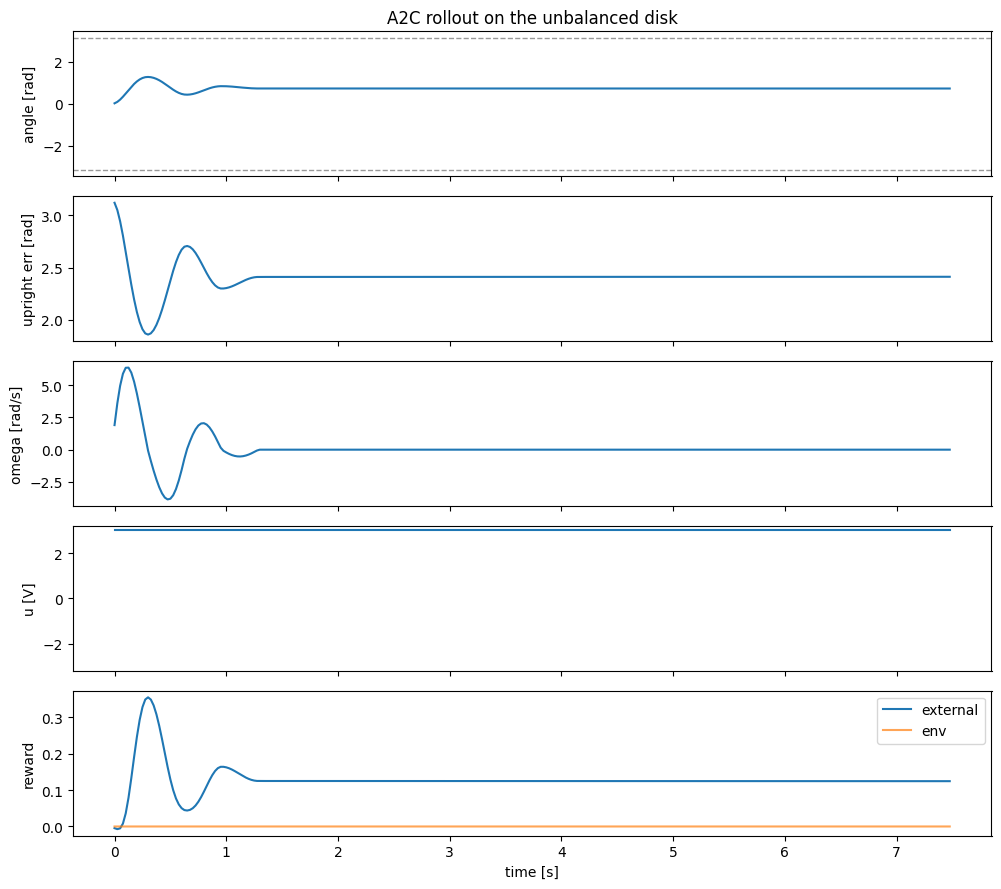

In [6]:
time_axis = np.arange(len(reward_hist)) * 0.025
angle_wrapped = np.array([info["theta_wrapped"] for info in info_hist])
omega = np.array([info["omega"] for info in info_hist])
upright_error = np.array([info["upright_error"] for info in info_hist])
env_reward_hist = np.array([info["env_reward"] for info in info_hist])

fig, axs = plt.subplots(5, 1, figsize=(10, 9), sharex=True)
axs[0].plot(time_axis, angle_wrapped)
axs[0].axhline(np.pi, color="k", linestyle="--", linewidth=1, alpha=0.4)
axs[0].axhline(-np.pi, color="k", linestyle="--", linewidth=1, alpha=0.4)
axs[0].set_ylabel("angle [rad]")
axs[0].set_title("A2C rollout on the unbalanced disk")

axs[1].plot(time_axis, upright_error)
axs[1].set_ylabel("upright err [rad]")

axs[2].plot(time_axis, omega)
axs[2].set_ylabel("omega [rad/s]")

axs[3].plot(time_axis, action_hist)
axs[3].set_ylabel("u [V]")
axs[3].set_ylim(-3.2, 3.2)

axs[4].plot(time_axis, reward_hist, label="external")
axs[4].plot(time_axis, env_reward_hist, label="env", alpha=0.7)
axs[4].set_ylabel("reward")
axs[4].set_xlabel("time [s]")
axs[4].legend()

fig.tight_layout()
plt.show()


## 5. Watch the learned controller

Run this last cell after training. It opens the unbalanced disk render window and simulates a longer A2C-controlled run so you have time to see whether it balances.


In [7]:
sim_obs, sim_actions, sim_rewards, sim_infos = rollout(
    model,
    deterministic=True,
    seed=SEED + 2,
    render=True,
    sleep_s=1 / 50,
    max_steps=SIMULATION_STEPS,
)

sim_upright_errors = np.array([info["upright_error"] for info in sim_infos])
sim_env_rewards = np.array([info["env_reward"] for info in sim_infos])
print(f"simulation steps: {len(sim_rewards)}")
print(f"simulation external return: {sim_rewards.sum():.2f}")
print(f"simulation environment return: {sim_env_rewards.sum():.2f}")
print(f"mean upright error: {sim_upright_errors.mean():.3f} rad")
print(f"final upright error: {sim_upright_errors[-1]:.3f} rad")
print(f"max |u|: {np.abs(sim_actions).max():.2f} V")


simulation steps: 1200
simulation external return: 149.71
simulation environment return: 0.00
mean upright error: 2.412 rad
final upright error: 2.416 rad
max |u|: 3.00 V
